In [62]:
import sys
import torch
import matplotlib.pyplot as plt
import numpy as np
from architecture.session_bigdata import Session, egeofno_ver1, egeofno_ver2, \
    egeofno_ver3, egeofno_ver4, svdfno_ver1, svdfno_ver2, svdfno_ver3, svdfno_ver4, fno_ver3


######### FIX MATRIX PLOTTING TAMALE #####
N_train = 40000
data_folder = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_torch/"
data_dir = "/home/emastr/deep-micro-slip-model/data/micro_geometries_boundcurv_repar_256_torch/data_0.torch"
save_dir = "/mnt/data0/emastr/article_training_hugedata/"
fig_dir = "/home/emastr/deep-micro-slip-model/data/"

device = "cpu"

option=1
if option == 1:
    name = "fno_ver2"
    label = "Geo FNO"
    net_gen = egeofno_ver2
else:
    name = "fno_vanilla_ver3"
    label = "Vanilla FNO"
    net_gen = fno_ver3
    
colors = ["steelblue", "indianred"]

def load_nets():
    nets = []
    losses_train = []
    losses_test = []
    #plt.figure(figsize=(8,8))
    for seed in [0, 1, 2, 3, 4, 5]:#, 4, 5]:
        #save_name = f"svdfno_ver{idx}_seed{seed}"
        save_name = f"{name}_seed{seed}"
        save = torch.load(f"{save_dir}{save_name}_{N_train}.Torch")
        state_dict = save["state dict"]
        net_settings = save["settings"]
        losses_train.append(save["trainloss"])
        losses_test.append(save["testloss"])
        #print(list(save.keys()))
        net = net_gen(device=device)
        net.load_state_dict(state_dict)
        nets.append(net)
    return nets, net_settings, losses_train, losses_test
    
nets, net_settings, losses_train, losses_test = load_nets()
net_settings["device"] = device
net_settings["num_pts"] = 256
net_settings["dtype"] = torch.float32

## Load train/test data and evaluate

In [63]:
print(torch.load(data_folder + "data_big_clean.torch")["X"].shape)

print(torch.load(data_folder + "data_big_0.torch")["X"].shape)

torch.Size([19999, 12, 256])
torch.Size([20000, 12, 256])


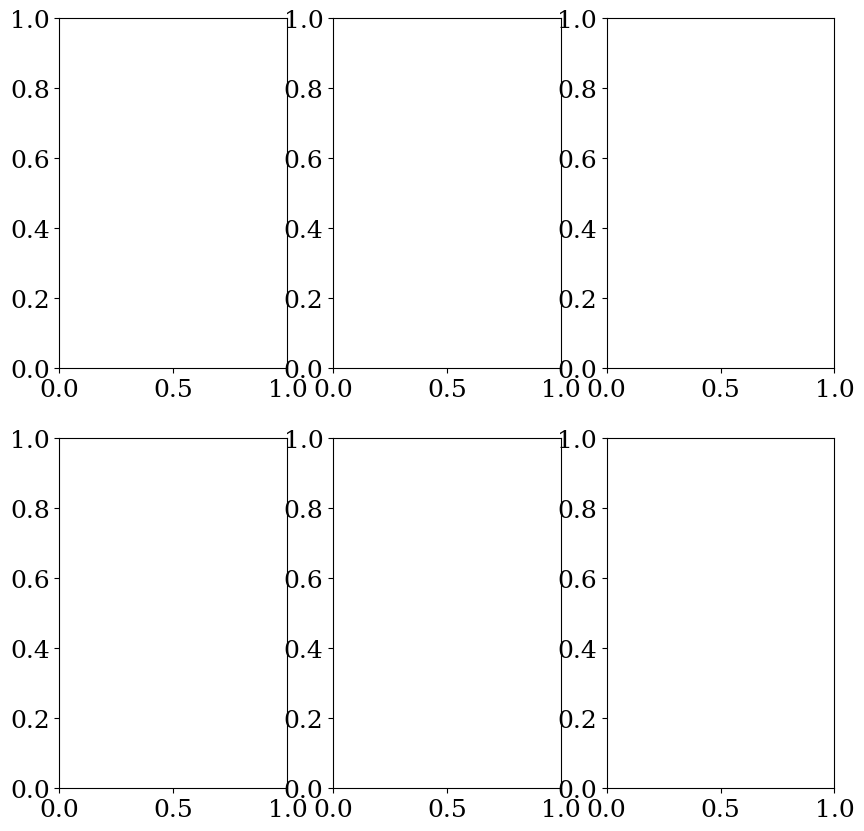

In [64]:
def loss(Y_net, Y_train):
        return torch.mean((Y_net - Y_train)**2, axis=(1, 2))**0.5 / torch.mean(Y_train**2, axis=(1, 2))**0.5

ses = Session(nets[0], "test", weight_decay=0.0, path_data=data_folder, save_dir=save_dir, dash_dir=fig_dir, device=device, seed=0)
data = ses.get_data(ses.net, ses.path_data + f"data_big_{0}.torch", ses.device)   
(X_train, Y_train)  = data[:]

losses = []
for i in [0]:#range(len(nets)):
        losses.append(loss(nets[i](X_train), Y_train))

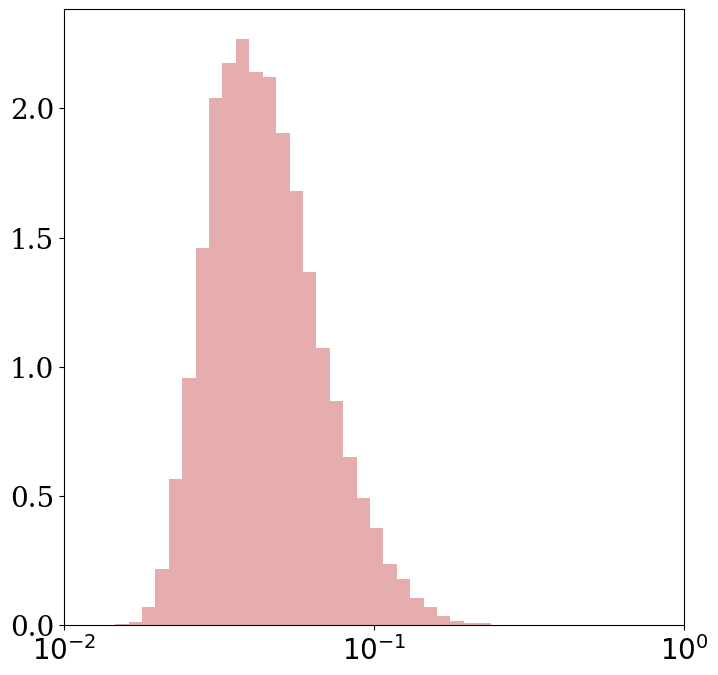

In [65]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 20
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

plt.figure(figsize=(8,8))
plt.hist(torch.log10(losses[0]).detach().numpy(), bins=30, alpha=0.5, label=f"seed {i}", density=True, color="indianred")
plt.vlines(torch.log10(torch.median(losses[0])).detach().numpy(), 0, 2, color="black", label="mean")
plt.xticks(np.arange(-2, 1, 1), ["$10^{" + f"{i}" + "}$" for i in np.arange(-2, 1, 1)])
plt.show()

(39602,) (39602,)


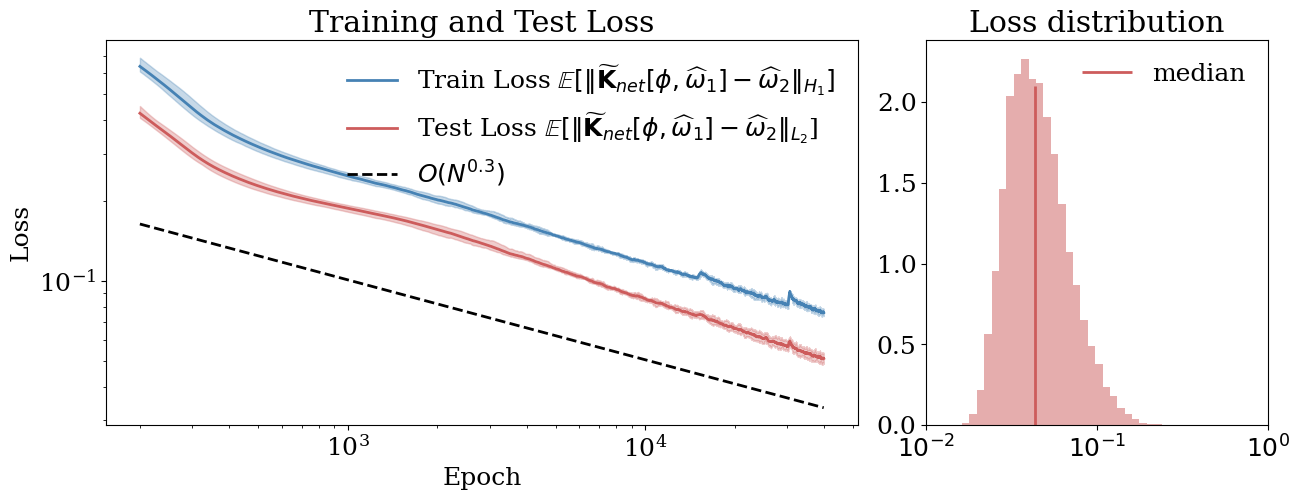

In [70]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (8,8)
matplotlib.rcParams['font.size'] = 18
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

def rolling_average(data, window_size):
    smooth_data = [np.convolve(d, np.ones(window_size), 'valid') / window_size for d in data]
    epochs = np.arange(window_size//2, len(data[0]) - window_size//2+1)
    return epochs, smooth_data
    
epochs_train, losses_train_avg = rolling_average(losses_train, 400)
epochs_test, losses_test_avg = rolling_average(losses_test, 400)

print(epochs_train.shape, losses_train_avg[0].shape)

max_loss_train = np.max(np.array(losses_train_avg), axis=0)
min_loss_train = np.min(np.array(losses_train_avg), axis=0)
mean_loss_train = np.mean(np.array(losses_train_avg), axis=0)

max_loss_test = np.max(np.array(losses_test_avg), axis=0)
min_loss_test = np.min(np.array(losses_test_avg), axis=0)
mean_loss_test = np.mean(np.array(losses_test_avg), axis=0)

plt.figure(figsize=(15,5))

plt.subplot2grid((1,3), (0,0), colspan=2)
plt.plot(epochs_train, mean_loss_train, label="Train Loss $\\mathbb{E}[\\|\\widetilde{\\mathbf{K}}_{net}[\\phi, \\widehat{\\omega}_1]-\\widehat{\\omega}_2\\|_{H_1}]$", color=colors[0])
plt.fill_between(epochs_train, min_loss_train, max_loss_train, alpha=0.3, color=colors[0])

plt.plot(epochs_test, mean_loss_test, color=colors[1], label="Test Loss $\\mathbb{E}[\\|\\widetilde{\\mathbf{K}}_{net}[\\phi, \\widehat{\\omega}_1]-\\widehat{\\omega}_2\\|_{L_2}$]")
plt.fill_between(epochs_test, min_loss_test, max_loss_test, alpha=0.3, color=colors[1])

## Reference O(1/N) line
plt.plot(epochs_train, 0.8/epochs_train**(0.3), color="black", linestyle="--", label="$O(N^{0.3})$")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.xscale("log")
plt.legend(frameon=False)
plt.title(f"Training and Test Loss")


plt.subplot2grid((1,3), (0,2), colspan=1)
plt.title("Loss distribution")
plt.hist(torch.log10(losses[0]).detach().numpy(), bins=30, alpha=0.5, density=True, color="indianred")
median = torch.log10(torch.median(losses[0][~torch.isnan(losses[0])])).item()
plt.vlines(median, 0, 2.1, color="indianred", linestyle='-', label="median")
plt.xticks(np.arange(-2, 1, 1), ["$10^{" + f"{i}" + "}$" for i in np.arange(-2, 1, 1)])
plt.legend(frameon=False)

plt.savefig(f"{fig_dir}{name}_loss_{N_train}.pdf", bbox_inches="tight")